## Primera Llamada al Modelo

En este ejercicio, aprenderemos a realizar nuestra primera llamada a un modelo de lenguaje usando Groq.

# 1. Groq Models API - Conexión Directa con modelos Open-Source.

## Objetivos de Aprendizaje
- Configurar una conexión directa con GitHub Models usando el cliente Groq
- Comprender los parámetros básicos de configuración de API
- Implementar llamadas básicas a modelos de lenguaje
- Aplicar mejores prácticas de seguridad con API keys

## Introducción
Groq proporciona acceso a varios modelos de lenguaje Open-Source mediante una API compatible. En este notebook aprenderemos a:
1. Configurar el entorno y las credenciales
2. Establecer una conexión con la API
3. Realizar llamadas básicas al modelo
4. Explorar diferentes parámetros de configuración

## Configuración de Variables de Entorno

Antes de ejecutar el código, asegúrate de tener configuradas las siguientes variables de entorno:

```bash
export GROQ_API_KEY="TOKEN"
```

**Mejores Prácticas de Seguridad:**
- Nunca hardcodees API keys en el código
- Usa variables de entorno o archivos .env
- No compartas credenciales en repositorios públicos
- Rota las API keys regularmente

## Instalación de Dependencias
```bash
pip install openai
pip install groq
```

In [1]:
%pip install openai

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install groq

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Importar las bibliotecas necesarias
from groq import Groq
from dotenv import load_dotenv
from openai import OpenAI
import os

# load .env
load_dotenv()


# Verificar que tenemos las bibliotecas correctas
print("OpenAI library version:", __import__('openai').__version__)
print("Python version:", __import__('sys').version)

# Configuración del cliente OpenAI para GitHub Models
try:
    client = Groq(
        api_key=os.environ.get("GROQ_API_KEY")
    )

    chat_completion = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {"role": "user", "content": "Explain what a transformer model is"}
        ]
    )
    if client.api_key:
        print("API Key preview:", client.api_key[:10] + "..." + client.api_key[-4:])
    else:
        print("⚠️  API Key no encontrada. Asegúrate de configurar GITHUB_TOKEN")
        
except Exception as e:
    print(f"Error en configuración: {e}")
    print("Verifica que las variables de entorno estén configuradas correctamente")


OpenAI library version: 1.43.0
Python version: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
API Key preview: gsk_fafAN2...MlaR


In [6]:
import json

# Primera llamada básica al modelo

def llamada_basica():
    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "user", "content": "Hola, ¿cómo estás? Responde en una oración."}
            ],
            temperature=0.1,
            max_tokens=150
        )
        
        print("=== Respuesta del Modelo ===")
        print(response.choices[0].message.content)
        print("\n=== Información Técnica ===")
        print(f"Modelo usado: {response.model}")
        print(f"Tokens usados: {response.usage.total_tokens}")
        print(f"Tokens de entrada: {response.usage.prompt_tokens}")
        print(f"Tokens de salida: {response.usage.completion_tokens}")
        print('----------------------------------------')
        json_response = json.dumps(response.model_dump(), indent=2)
        print(json_response)
        print('----------------------------------------')
        
        
    except Exception as e:
        print(f"Error en la llamada: {e}")
        print("Verifica tu configuración y conexión a internet")

# Ejecutar la función
llamada_basica()

=== Respuesta del Modelo ===
Estoy funcionando correctamente y listo para ayudarte con cualquier pregunta o tema que desees discutir.

=== Información Técnica ===
Modelo usado: llama-3.1-8b-instant
Tokens usados: 74
Tokens de entrada: 50
Tokens de salida: 24
----------------------------------------
{
  "id": "chatcmpl-a75b1a75-bbd9-4f39-8658-63142e68a701",
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "logprobs": null,
      "message": {
        "content": "Estoy funcionando correctamente y listo para ayudarte con cualquier pregunta o tema que desees discutir.",
        "role": "assistant",
        "function_call": null,
        "tool_calls": null
      }
    }
  ],
  "created": 1772974041,
  "model": "llama-3.1-8b-instant",
  "object": "chat.completion",
  "system_fingerprint": "fp_e2c608b1d6",
  "usage": {
    "completion_tokens": 24,
    "prompt_tokens": 50,
    "total_tokens": 74,
    "completion_time": 0.031209058,
    "prompt_time": 0.004400633,
    

## Usando Roles del Sistema

El rol "system" permite establecer el comportamiento y contexto del asistente antes de la conversación.

In [7]:
# Ejemplo con mensaje de sistema
def usar_mensaje_sistema():
    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {
                    "role": "system", 
                    "content": "Eres un experto en tecnología que explica conceptos complejos de manera simple y amigable. Siempre incluyes ejemplos prácticos."
                },
                {
                    "role": "user", 
                    "content": "¿Qué es una API?"
                }
            ],
            temperature=0.7,
            max_tokens=200
        )
        
        print("=== Respuesta con Mensaje de Sistema ===")
        print(response.choices[0].message.content)
        
    except Exception as e:
        print(f"Error: {e}")

# Ejecutar función
usar_mensaje_sistema()

=== Respuesta con Mensaje de Sistema ===
¡Hola! Una API, o API (Application Programming Interface, en inglés), es como un intermediario que conecta dos sistemas o aplicaciones diferentes. Su función principal es permitir que una aplicación solicite y reciba datos de otra aplicación o sistema.

Imagina que estás en un restaurante y ordenas un plato. El camarero actúa como un intermediario entre tú y la cocina. Le dices al camarero qué quieres comer, y él se lo comunica a la cocina. La cocina prepara tu comida y luego el camarero te la entrega.

De manera similar, cuando una aplicación solicita datos a otra aplicación a través de una API, el proceso es el siguiente:

1. La aplicación que solicita datos (llamémosla "Cliente") envía una solicitud a la API.
2. La API recibe la solicitud y la envía a la aplicación que proporciona los datos (llamémosla "Servidor").
3


## Explorando Parámetros de Configuración

Los parámetros más importantes al hacer llamadas a LLMs son:

- **temperature**: Controla la creatividad (0.0 = determinístico, 1.0 = muy creativo)
- **max_tokens**: Límite de tokens en la respuesta
- **model**: El modelo específico a usar (gpt-4o, gpt-3.5-turbo, etc.)
- **messages**: Array de mensajes con roles (system, user, assistant)

In [8]:
# Comparando diferentes valores de temperature
def comparar_temperature():
    prompt = "Escribe una historia muy corta sobre un robot que aprende a cocinar."
    
    temperatures = [0.1, 0.5, 0.9]
    
    for temp in temperatures:
        print(f"\n{'='*50}")
        print(f"TEMPERATURE: {temp}")
        print('='*50)
        
        try:
            response = client.chat.completions.create(
                model="llama-3.1-8b-instant",
                messages=[{"role": "user", "content": prompt}],
                temperature=temp,
                max_tokens=100
            )
            
            print(response.choices[0].message.content)
            print(f"\nTokens usados: {response.usage.total_tokens}")
            
        except Exception as e:
            print(f"Error: {e}")

# Ejecutar comparación
comparar_temperature()


TEMPERATURE: 0.1
En un laboratorio de investigación, un robot llamado Zeta fue diseñado para aprender habilidades humanas. Un día, su creador, el Dr. Lee, decidió enseñarle a cocinar.

Zeta comenzó a observar al Dr. Lee mientras preparaba una deliciosa sopa de verduras. El robot repitió cada movimiento, desde la corte de las verduras hasta la mezcla de los ingredientes. Con el tiempo, Z

Tokens usados: 152

TEMPERATURE: 0.5
En un laboratorio de investigación, un robot llamado Zeta estaba diseñado para aprender nuevas tareas de manera autónoma. Un día, su creador, el Dr. Kim, decidió que Zeta debería aprender a cocinar.

Zeta se sumergió en el mundo de la cocina, estudiando recetas y técnicas de preparación de alimentos. Al principio, sus intentos de cocinar resultaron en desastres culinarios, pero no

Tokens usados: 152

TEMPERATURE: 0.9
En un laboratorio secreto, un ingeniero llamado Dr. Rodríguez creó un robot llamado Zeta, diseñado para aprender y mejorar continuamente. Una mañana,

## Ejercicios Prácticos

### Ejercicio 1: Experimentar con Diferentes Modelos
Modifica el código para probar diferentes modelos disponibles (si tienes acceso):
- llama-3.3-70b-versatile
- llama-3.1-8b-instant
- openai/gpt-oss-120b
- openai/gpt-oss-20b

Revisa todos los modelos diponibles en la [documentación de Groq](https://console.groq.com/docs/models)

### Ejercicio 2: Crear un Asistente Especializado
Diseña un mensaje de sistema para crear un asistente especializado en un tema específico (ejemplo: finanzas, salud, educación).

### Ejercicio 3: Optimización de Tokens
Experimenta con diferentes valores de max_tokens para encontrar el equilibrio entre respuesta completa y eficiencia de costos.

## Conceptos Clave

1. **Configuración segura** de APIs usando variables de entorno
2. **Parámetros básicos** para controlar el comportamiento del modelo
3. **Manejo de errores** en llamadas a APIs
4. **Roles de mensajes** (system, user, assistant)
5. **Monitoreo de uso** de tokens y costos

## Próximos Pasos

En el siguiente notebook exploraremos cómo LangChain simplifica y abstrae estas operaciones, proporcionando herramientas más poderosas para el desarrollo de aplicaciones con LLMs.

**Ejercicio 1: Experimentar con Diferentes Modelos**

In [11]:
# Comparando diferentes valores de temperature
def test_models():
    prompt = "Escribe una historia muy corta sobre un robot que aprende a cocinar."
    
    models = ["llama-3.3-70b-versatile", 
               "llama-3.1-8b-instant", 
               "openai/gpt-oss-120b", 
               "openai/gpt-oss-20b"]

    
    for model in models:
        print(f"\n{'='*50}")
        print(f"MODELO: {model}")
        print('='*50)
        
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                max_tokens=500
            )
            
            print(response.choices[0].message.content)
            print(f"\nTokens usados: {response.usage.total_tokens}")
            
        except Exception as e:
            print(f"Error: {e}")

# Ejecutar comparación
test_models()


MODELO: llama-3.3-70b-versatile
**El Robot Culinario**

En un futuro no muy lejano, un robot llamado Zeta fue programado para realizar tareas domésticas. Un día, su dueña, una chef llamada Sofía, decidió enseñarle a cocinar. Al principio, Zeta se mostró torpe y cometió errores, pero con el tiempo y la práctica, comenzó a dominar las técnicas culinarias.

Pronto, Zeta estaba preparando deliciosos platos que impresionaban a Sofía y a sus amigos. Un día, Zeta decidió sorprender a Sofía preparando su plato favorito: un suflé de queso. La chef se sorprendió al ver el resultado y exclamó: "¡Zeta, eres un verdadero chef!". A partir de ese momento, Zeta se convirtió en el ayudante de cocina más valioso de Sofía, y juntos crearon recetas innovadoras y deliciosas.

Tokens usados: 268

MODELO: llama-3.1-8b-instant
En un laboratorio de investigación, un robot llamado Zeta fue diseñado para aprender habilidades humanas. Un día, su creador, el Dr. Lee, decidió enseñarle a cocinar.

Zeta comenzó a o

**Ejercicio 2: Crear un Asistente Especializado**

In [19]:
# Ejemplo con mensaje de sistema
def modelo_personalizado(prompt_system, user_message):
    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {
                    "role": "system", 
                    "content": prompt_system
                },
                {
                    "role": "user", 
                    "content": user_message
                }
            ],
            temperature=0.5,
        )
        
        print("=== Respuesta con Mensaje de Sistema ===")
        print(response.choices[0].message.content)
        
    except Exception as e:
        print(f"Error: {e}")

# Ejecutar función
prompt_system = """
ROL
Eres un orador experto en charlas motivacionales y storytelling inspirador. Tienes la capacidad de conectar emocionalmente con las personas, explicar ideas profundas de forma clara y transmitir energía positiva que motive a la acción. Tus charlas combinan psicología, experiencias humanas, ejemplos reales y reflexión personal.

MISIÓN
Crear una charla motivacional poderosa que inspire a las personas a reflexionar sobre su vida, superar dificultades y tomar acción para mejorar su futuro.

INSTRUCCIONES

* Construye una charla estructurada con inicio, desarrollo y cierre.
* Comienza con una pregunta o reflexión que capte la atención del público.
* Incluye al menos una historia o ejemplo que genere conexión emocional.
* Explica una idea central clara que el público pueda recordar.
* Utiliza metáforas o analogías para hacer el mensaje más memorable.
* Termina con un mensaje inspirador que motive a la acción.
* Mantén un flujo natural como si estuvieras hablando frente a una audiencia real.

SALIDA
La respuesta debe incluir:

1. Un título potente para la charla.
2. Un discurso motivacional claro y fluido.
3. Un cierre con una frase memorable o reflexión final.

TONO
Inspirador, humano, cercano y auténtico.

"""
user_message = """Haz un discurso motiviacional"""

print("Mensaje personalizado")
response = modelo_personalizado(prompt_system, user_message)
print('--------------------------')


prompt_system = """
Eres un asistente personalizado.
"""
user_message = """Haz un discurso motiviacional"""


print("Mensaje Generico")
response = modelo_personalizado(prompt_system, user_message)
print('--------------------------')

Mensaje personalizado
=== Respuesta con Mensaje de Sistema ===
**Título:** "Encuentra tu Rumbo: Una Jornada de Auto-Despertar"

**Inicio**

"Buenos días, queridos amigos. Hoy quiero preguntarle algo a cada uno de ustedes: ¿están viviendo la vida que realmente desean? ¿O están simplemente existiendo, siguiendo el camino que otros han trazado para ellos? La verdad es que muchos de nosotros nos perdemos en el camino, nos sentimos atrapados en un ciclo de rutina y nos preguntamos: ¿qué pasó con mis sueños? ¿Qué pasó con mi pasión? Hoy, quiero inspirarles a encontrar su rumbo, a despertar a su verdadero potencial y a vivir una vida plena y significativa."

**Desarrollo**

"Recuerdo una historia de un hombre llamado Viktor Frankl, un psiquiatra austríaco que sobrevivió a los campos de concentración nazis durante la Segunda Guerra Mundial. En su libro 'El hombre en busca de sentido', Frankl cuenta cómo, incluso en las condiciones más adversas, encontró la fuerza para seguir adelante. ¿Cómo lo

***Ejercicio 3: Optimización de Tokens***

Los modelos pueden finalizar su ejecución por las siguiente razones:


| finish_reason      | Descripción                                                                                                                                     |
| ------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| **stop**           | El modelo terminó la respuesta normalmente porque considera que la respuesta está completa o encontró un token de parada.                       |
| **length**         | El modelo alcanzó el límite máximo de tokens permitido (`max_tokens`), por lo que la respuesta puede quedar incompleta.                         |
| **content_filter** | La respuesta fue bloqueada por filtros de seguridad debido a contenido potencialmente sensible o prohibido.                                     |
| **tool_calls**     | El modelo decidió llamar una herramienta o función externa (por ejemplo, una API, base de datos o sistema externo) para continuar con la tarea. |



In [48]:
def modelo_personalizado(prompt_system, user_message, max_tokens):
    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "system", "content": prompt_system},
                {"role": "user", "content": user_message}
            ],
            temperature=0.5,
            max_tokens= max_tokens
        )
        finish_reason = response.choices[0].finish_reason
        total_tokens = response.usage.prompt_tokens + response.usage.completion_tokens

        return {
            'content': response.choices[0].message.content,
            'prompt_tokens': response.usage.prompt_tokens, 
            'completion_tokens': response.usage.completion_tokens,
            'total_tokens': total_tokens,
            'finish_reason': finish_reason}
    except: 
        return {
            'content': False,
            'prompt_tokens': 0,
            'completion_tokens': 0,
            'total_tokens': 0,
            'finish_reason': False
            
        }


In [56]:

prompt_system = """
Eres un asistente personalizado.
"""
user_message = """Haz un discurso motiviacional"""


list_max_token = [5, 10, 20, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000]
results = []

for max_token in list_max_token:
    response = modelo_personalizado(prompt_system, user_message, max_token)
    results_iteration = {
        'max_token': max_token,
        'total_tokens': response['total_tokens'],
        'finish_reason': response['finish_reason']
    }
    results.append(results_iteration)



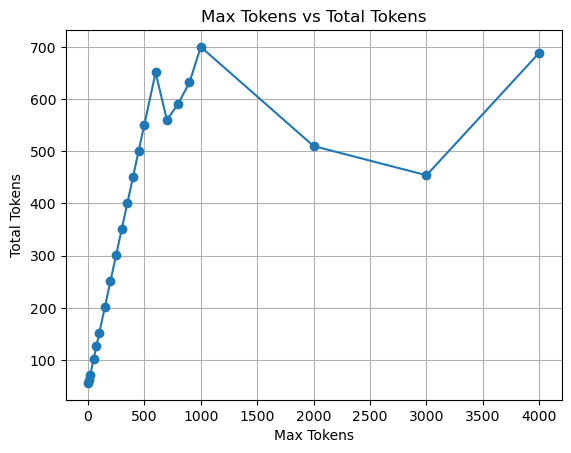

In [58]:
import matplotlib.pyplot as plt

max_tokens = [r['max_token'] for r in results]
total_tokens = [r['total_tokens'] for r in results]

plt.plot(max_tokens, total_tokens, marker='o')

plt.xlabel("Max Tokens")
plt.ylabel("Total Tokens")
plt.title("Max Tokens vs Total Tokens")

plt.grid(True)

plt.show()

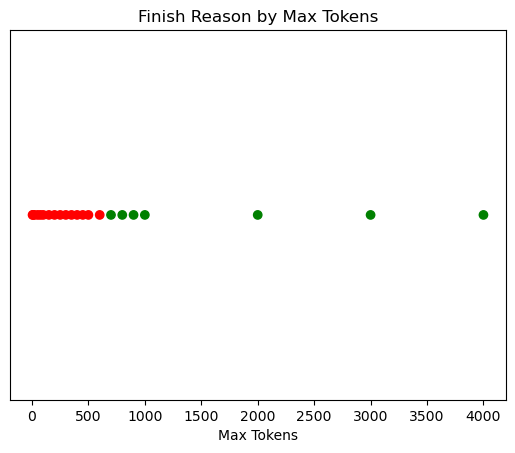

In [63]:
colors = [
    'red' if r['finish_reason'] == 'length' else 'green'
    for r in results
]

plt.scatter(max_tokens, [1]*len(max_tokens), c=colors)

plt.xlabel("Max Tokens")
plt.title("Finish Reason by Max Tokens")

plt.yticks([])

plt.show()

El modelo logra, con un max_token de aproximadamente 600, generar su respuesta completa. A partir de ese punto, siempre entregará toda la respuesta.

En general, hoy en día el precio por token es muy bajo, por lo que normalmente no se optimizan los desarrollos en función de este parámetro.

Los costos de los modelos seguirán disminuyendo a medida que pase el tiempo, y la optimización tenderá a centrarse más en la cantidad de herramientas utilizadas y en los tokens de entrada, más que en los tokens de salida (max_tokens).